# TaskBoard Dataset EDA

Inspect collected `TASK_BOARD` YOLO pose labels, keypoint distributions, and sample overlays.

In [1]:
from pathlib import Path
import math
import random
import re

import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
import numpy as np
import yaml

try:
    import pandas as pd
except ImportError:
    pd = None


def find_ws_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "src" / "ais").exists() and (path / "data").exists():
            return path
        if (path / "pixi.toml").exists() and (path / "ais").exists():
            return path.parent
        nested = path / "ws_aic"
        if (nested / "src" / "ais").exists() and (nested / "data").exists():
            return nested
    raise RuntimeError("Could not find ws_aic root from current working directory.")


WS_ROOT = find_ws_root(Path.cwd().resolve())
TARGET = "TASK_BOARD"
DATASET_DIR = WS_ROOT / "data" / "yolo" / "approach" / TARGET
DATA_YAML = DATASET_DIR / "data.yaml"
IMAGE_EXTS = {".bmp", ".jpeg", ".jpg", ".png", ".tif", ".tiff", ".webp"}

if not DATA_YAML.exists():
    raise FileNotFoundError(f"Missing data.yaml: {DATA_YAML}")

cfg = yaml.safe_load(DATA_YAML.read_text(encoding="utf-8"))
kpt_names_map = cfg.get("kpt_names", {})
KEYPOINT_NAMES = kpt_names_map.get(0) or kpt_names_map.get("0") or [
    "board_neg_x_pos_y",
    "board_pos_x_pos_y",
    "board_pos_x_neg_y",
    "board_neg_x_neg_y",
]
KEYPOINT_COUNT = int(cfg.get("kpt_shape", [len(KEYPOINT_NAMES), 2])[0])
KEYPOINT_DIMS = int(cfg.get("kpt_shape", [KEYPOINT_COUNT, 2])[1])
CLASS_NAMES = cfg.get("names", {0: "task_board"})

TASK_BOARD_OBJECT_POINTS_M = np.array(
    [
        [-0.1500, 0.2125, 0.0120],
        [0.1500, 0.2125, 0.0120],
        [0.1500, -0.2125, 0.0120],
        [-0.1500, -0.2125, 0.0120],
    ],
    dtype=np.float64,
)

print(f"WS_ROOT: {WS_ROOT}")
print(f"DATASET_DIR: {DATASET_DIR}")
print(f"KEYPOINT_NAMES: {KEYPOINT_NAMES}")
print(f"KEYPOINT_DIMS: {KEYPOINT_DIMS}")

WS_ROOT: /home/vsc/LLM_TUNE/AIC_Sejong/ws_aic
DATASET_DIR: /home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/data/yolo/approach/TASK_BOARD
KEYPOINT_NAMES: ['board_neg_x_pos_y', 'board_pos_x_pos_y', 'board_pos_x_neg_y', 'board_neg_x_neg_y']
KEYPOINT_DIMS: 2


In [2]:
# EDA options
SPLITS = ["train", "val"]
N_SAMPLES = 12
SEED = 7
IMAGE_FILTER = ""  # e.g. "center", "left", "right", or "ep00040"
SHOW_KEYPOINT_NAMES = True
FIG_COLS = 3

## Helpers

In [3]:
def resolve_dataset_path(path_value: str | Path) -> Path:
    path = Path(path_value).expanduser()
    if path.is_absolute():
        return path
    return (DATASET_DIR / path).resolve()


def split_image_dir(split: str) -> Path:
    return resolve_dataset_path(cfg[split])


def label_path_for_image(image_path: Path) -> Path:
    parts = list(image_path.parts)
    if "images" in parts:
        parts[parts.index("images")] = "labels"
        return Path(*parts).with_suffix(".txt")
    return image_path.with_suffix(".txt")


def iter_images(split: str) -> list[Path]:
    image_dir = split_image_dir(split)
    if not image_dir.exists():
        return []
    images = sorted(p for p in image_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTS)
    if IMAGE_FILTER:
        images = [p for p in images if IMAGE_FILTER in p.name]
    return images


def camera_from_name(image_path: Path) -> str:
    match = re.search(r"_(left|center|right)$", image_path.stem)
    return match.group(1) if match else "unknown"


def class_name(class_id: int) -> str:
    return CLASS_NAMES.get(class_id) or CLASS_NAMES.get(str(class_id)) or str(class_id)


def load_labels(label_path: Path) -> list[dict]:
    if not label_path.exists():
        return []
    labels = []
    for line_idx, line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), start=1):
        line = line.strip()
        if not line:
            continue
        values = np.array([float(v) for v in line.split()], dtype=np.float64)
        expected_cols = 5 + KEYPOINT_COUNT * KEYPOINT_DIMS
        if len(values) != expected_cols:
            raise ValueError(f"{label_path}:{line_idx} has {len(values)} columns, expected {expected_cols}")
        class_id = int(values[0])
        bbox_norm = values[1:5]
        kpts_norm = values[5:].reshape(KEYPOINT_COUNT, KEYPOINT_DIMS)[:, :2]
        labels.append(
            {
                "class_id": class_id,
                "class_name": class_name(class_id),
                "bbox_norm": bbox_norm,
                "kpts_norm": kpts_norm,
            }
        )
    return labels


def bbox_norm_to_px(bbox_norm: np.ndarray, image_w: int, image_h: int) -> tuple[float, float, float, float]:
    x_c, y_c, box_w, box_h = bbox_norm
    x = (x_c - box_w / 2.0) * image_w
    y = (y_c - box_h / 2.0) * image_h
    return x, y, box_w * image_w, box_h * image_h

## Dataset scan

In [4]:
rows = []
issues = []

for split in SPLITS:
    for image_path in iter_images(split):
        image = cv2.imread(str(image_path))
        if image is None:
            issues.append(f"failed to read image: {image_path}")
            continue
        image_h, image_w = image.shape[:2]
        label_path = label_path_for_image(image_path)
        labels = load_labels(label_path)
        if not labels:
            issues.append(f"missing or empty label: {label_path}")
            continue
        for label_idx, label in enumerate(labels):
            x, y, w, h = bbox_norm_to_px(label["bbox_norm"], image_w, image_h)
            row = {
                "split": split,
                "camera": camera_from_name(image_path),
                "image": str(image_path),
                "label": str(label_path),
                "label_idx": label_idx,
                "class_name": label["class_name"],
                "image_w": image_w,
                "image_h": image_h,
                "bbox_x_px": x,
                "bbox_y_px": y,
                "bbox_w_px": w,
                "bbox_h_px": h,
                "bbox_area_frac": float(label["bbox_norm"][2] * label["bbox_norm"][3]),
            }
            for kpt_idx, (kx, ky) in enumerate(label["kpts_norm"]):
                row[f"kpt{kpt_idx}_x"] = float(kx)
                row[f"kpt{kpt_idx}_y"] = float(ky)
            rows.append(row)

print(f"labels: {len(rows)}")
print(f"issues: {len(issues)}")
for issue in issues[:30]:
    print(issue)

if pd is not None:
    df = pd.DataFrame(rows)
    display(df.head())
    if not df.empty:
        display(df.groupby(["split", "camera"]).size().rename("labels"))
        display(df[["bbox_w_px", "bbox_h_px", "bbox_area_frac"]].describe())
else:
    df = rows
    for row in rows[:5]:
        print(row)

labels: 218
issues: 0


,split,camera,image,label,label_idx,class_name,image_w,image_h,bbox_x_px,bbox_y_px,...,bbox_h_px,bbox_area_frac,kpt0_x,kpt0_y,kpt1_x,kpt1_y,kpt2_x,kpt2_y,kpt3_x,kpt3_y
0,train,center,/home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/data/yolo...,/home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/data/yolo...,0,task_board,1152,1024,341.998848,132.427776,...,743.557120,0.332415,0.328446,0.179402,0.717210,0.179824,0.723092,0.798293,0.331951,0.805376
1,train,left,/home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/data/yolo...,/home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/data/yolo...,0,task_board,1152,1024,0.000000,35.750400,...,841.325568,0.637606,0.544006,0.091575,0.721744,0.466112,0.279679,0.799857,0.042949,0.430999
2,train,right,/home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/data/yolo...,/home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/data/yolo...,0,task_board,1152,1024,277.364736,0.000000,...,832.495616,0.616538,0.296182,0.425751,0.480955,0.042486,0.988857,0.367796,0.754566,0.755910
3,train,center,/home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/data/yolo...,/home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/data/yolo...,0,task_board,1152,1024,341.998848,132.427776,...,743.557120,0.332415,0.328446,0.179402,0.717210,0.179824,0.723092,0.798293,0.331951,0.805376
4,train,left,/home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/data/yolo...,/home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/data/yolo...,0,task_board,1152,1024,0.000000,35.750400,...,841.325568,0.637606,0.544006,0.091575,0.721744,0.466112,0.279679,0.799857,0.042949,0.430999


split  camera
train  center    45
       left      45
       right     54
val    center    23
       left      23
       right     28
Name: labels, dtype: int64

,bbox_w_px,bbox_h_px,bbox_area_frac
count,218.000000,218.000000,218.000000
mean,784.856041,820.923091,0.548809
std,127.076006,60.230728,0.109447
min,527.374080,715.336704,0.332415
25%,712.260864,769.332224,0.500839
50%,824.737536,833.703936,0.540117
75%,898.625664,876.430592,0.645859
max,920.414592,877.672448,0.684681


## Bbox and keypoint distributions

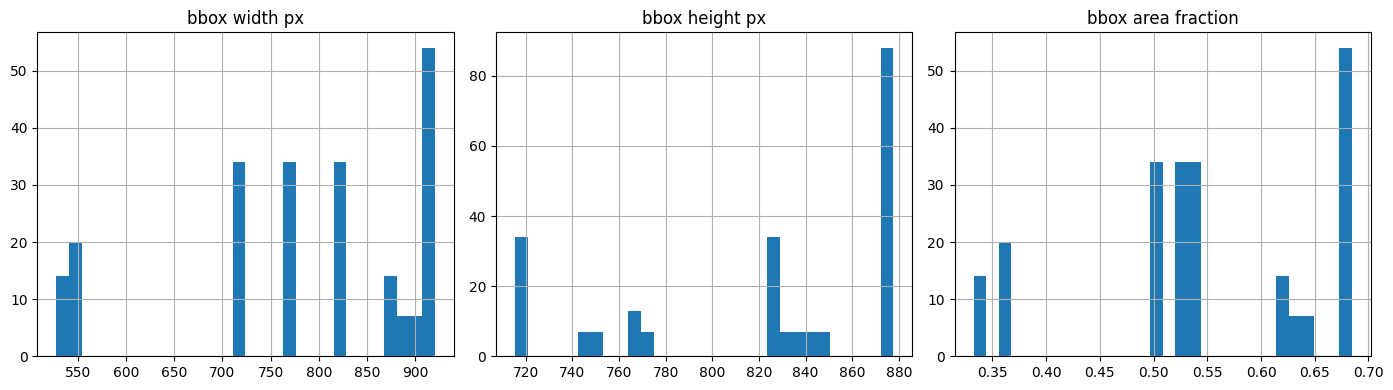

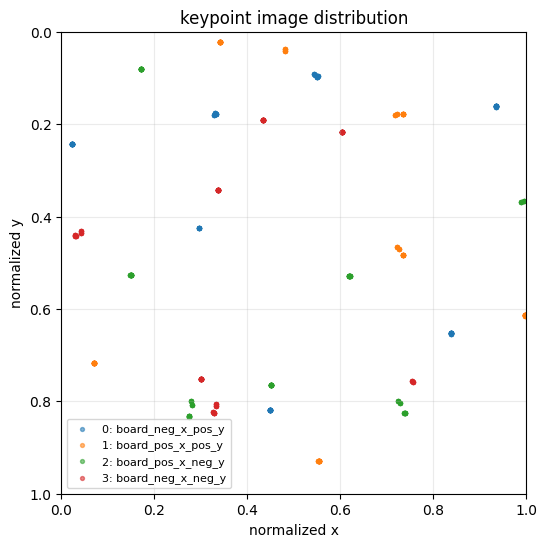

In [5]:
if pd is None:
    raise ImportError("Install pandas or skip this statistics cell.")
if df.empty:
    raise RuntimeError("No labels to plot.")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df["bbox_w_px"].hist(ax=axes[0], bins=30)
axes[0].set_title("bbox width px")
df["bbox_h_px"].hist(ax=axes[1], bins=30)
axes[1].set_title("bbox height px")
df["bbox_area_frac"].hist(ax=axes[2], bins=30)
axes[2].set_title("bbox area fraction")
plt.tight_layout()

fig, ax = plt.subplots(figsize=(6, 6))
for kpt_idx, name in enumerate(KEYPOINT_NAMES):
    ax.scatter(df[f"kpt{kpt_idx}_x"], df[f"kpt{kpt_idx}_y"], s=8, alpha=0.55, label=f"{kpt_idx}: {name}")
ax.set_xlim(0, 1)
ax.set_ylim(1, 0)
ax.set_xlabel("normalized x")
ax.set_ylabel("normalized y")
ax.set_title("keypoint image distribution")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

## Sample overlays

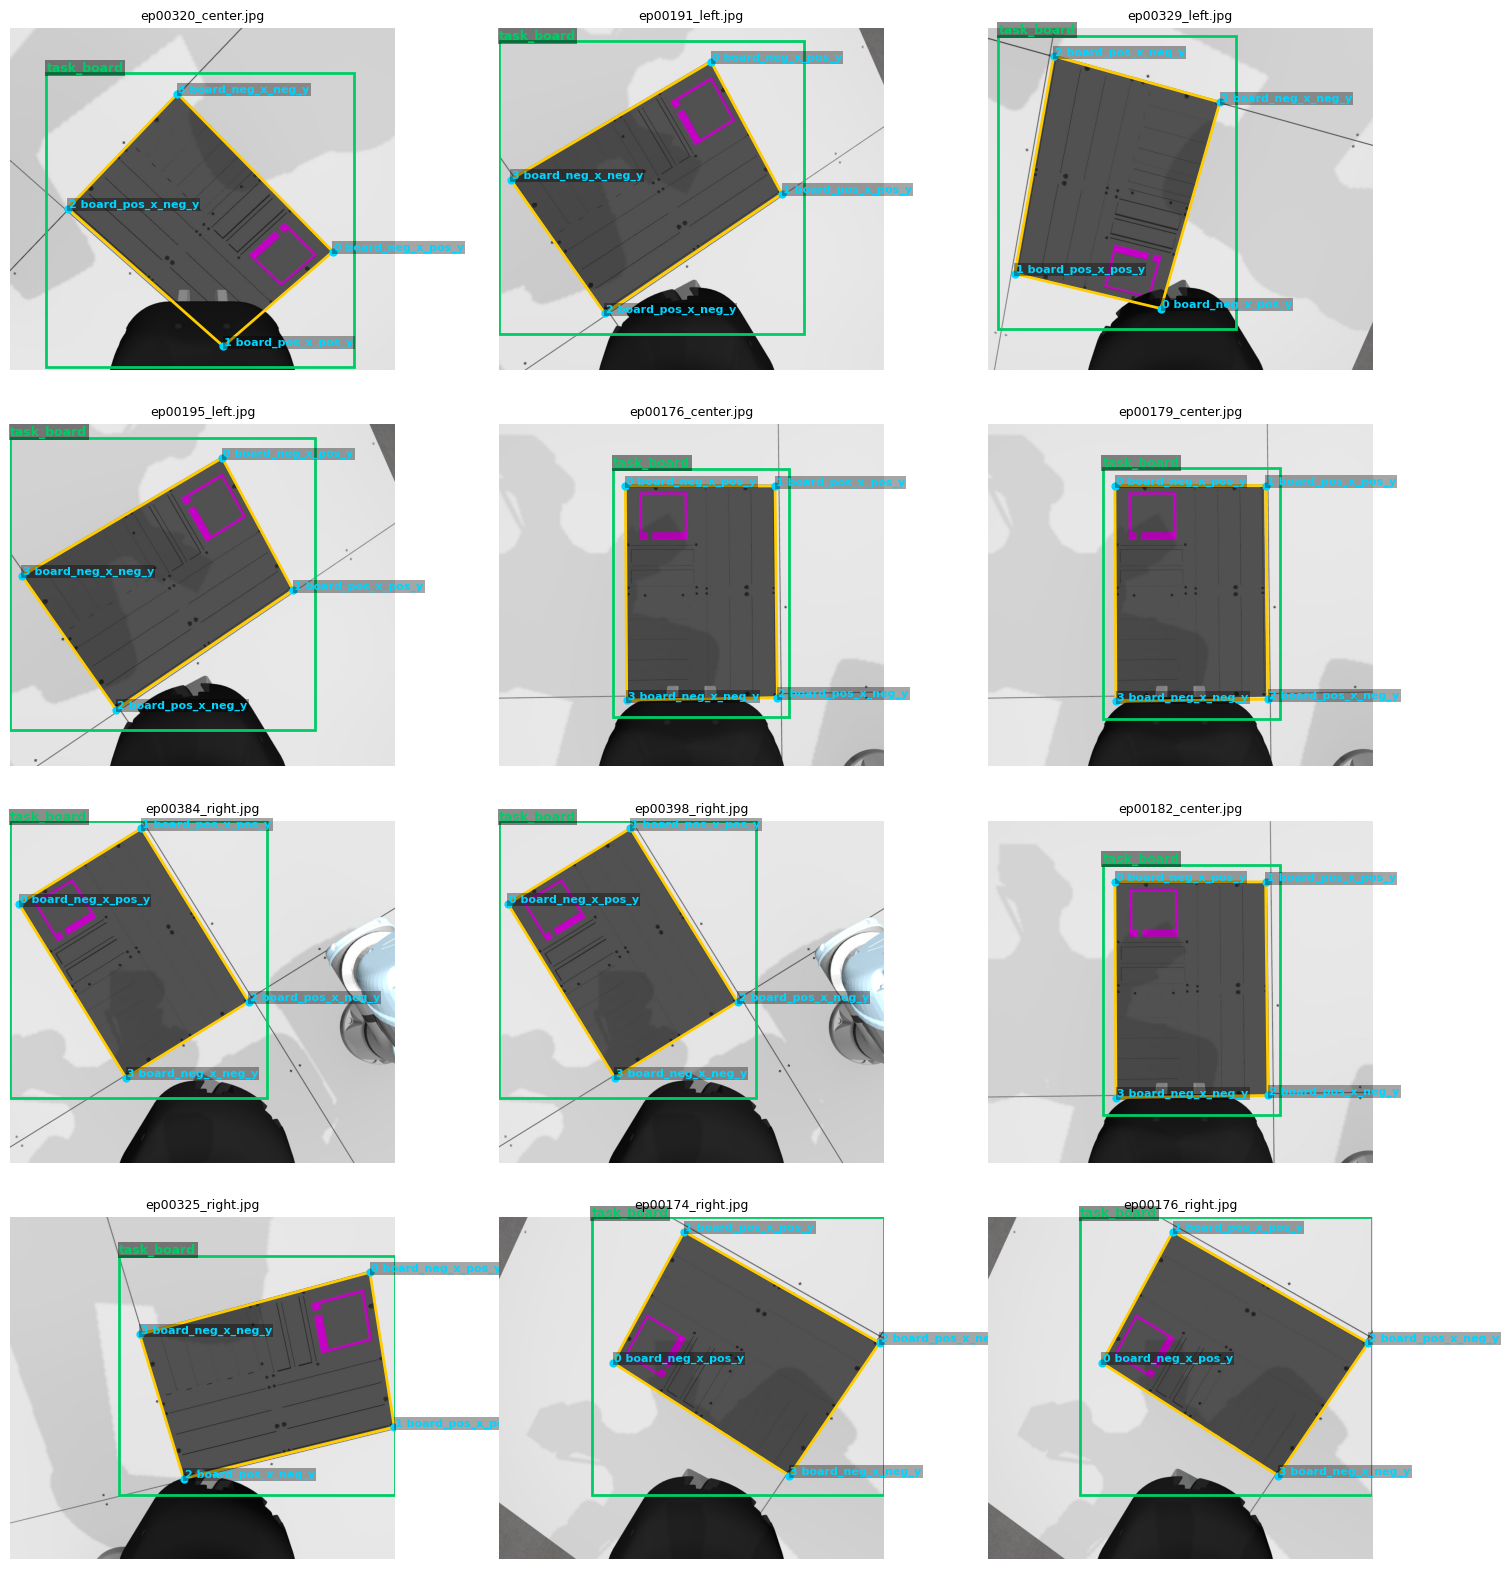

In [6]:
BOX_COLOR = "#00cc66"
KPT_COLOR = "#00d5ff"
EDGE_COLOR = "#ffcc00"


def draw_label(ax, label: dict, image_w: int, image_h: int) -> None:
    x, y, w, h = bbox_norm_to_px(label["bbox_norm"], image_w, image_h)
    ax.add_patch(Rectangle((x, y), w, h, fill=False, linewidth=2.0, edgecolor=BOX_COLOR))
    ax.text(
        x,
        max(0, y - 6),
        label["class_name"],
        color=BOX_COLOR,
        fontsize=9,
        weight="bold",
        bbox={"facecolor": "black", "alpha": 0.45, "pad": 1, "edgecolor": "none"},
    )

    pts = label["kpts_norm"] * np.array([image_w, image_h], dtype=np.float64)
    ax.add_patch(Polygon(pts, closed=True, fill=False, linewidth=2.0, edgecolor=EDGE_COLOR))
    for kpt_idx, (px, py) in enumerate(pts):
        ax.scatter([px], [py], s=24, color=KPT_COLOR)
        text = str(kpt_idx)
        if SHOW_KEYPOINT_NAMES and kpt_idx < len(KEYPOINT_NAMES):
            text = f"{kpt_idx} {KEYPOINT_NAMES[kpt_idx]}"
        ax.text(
            px + 3,
            py - 3,
            text,
            color=KPT_COLOR,
            fontsize=8,
            weight="bold",
            bbox={"facecolor": "black", "alpha": 0.35, "pad": 1, "edgecolor": "none"},
        )


images = []
for split in SPLITS:
    images.extend(iter_images(split))
if not images:
    raise RuntimeError(f"No images found under {DATASET_DIR}")

rng = random.Random(SEED)
samples = rng.sample(images, k=min(N_SAMPLES, len(images)))
rows_count = math.ceil(len(samples) / FIG_COLS)
fig, axes = plt.subplots(rows_count, FIG_COLS, figsize=(FIG_COLS * 5, rows_count * 4))
axes = np.array(axes).reshape(-1)

for ax, image_path in zip(axes, samples):
    image_bgr = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_h, image_w = image_rgb.shape[:2]
    ax.imshow(image_rgb)
    for label in load_labels(label_path_for_image(image_path)):
        draw_label(ax, label, image_w, image_h)
    ax.set_title(image_path.name, fontsize=9)
    ax.axis("off")

for ax in axes[len(samples):]:
    ax.axis("off")

plt.tight_layout()

## PnP object-point reference

In [7]:
for idx, (name, point) in enumerate(zip(KEYPOINT_NAMES, TASK_BOARD_OBJECT_POINTS_M)):
    print(f"{idx}: {name:18s} object_point_m={point.tolist()}")

print("\nUse these object points with the matching detected image keypoints for cv2.solvePnP.")

0: board_neg_x_pos_y  object_point_m=[-0.15, 0.2125, 0.012]
1: board_pos_x_pos_y  object_point_m=[0.15, 0.2125, 0.012]
2: board_pos_x_neg_y  object_point_m=[0.15, -0.2125, 0.012]
3: board_neg_x_neg_y  object_point_m=[-0.15, -0.2125, 0.012]

Use these object points with the matching detected image keypoints for cv2.solvePnP.
